# Cancer Biomarker Discovery from Gene Expression Data

**Lung cancer: GSE19804 (discovery) and GSE18842 (validation)**

**Question:** Which genes change consistently between lung tumors and the same patient's normal lung tissue, and does a small set of them still separate tumor from normal in a completely independent study?

**Pipeline**

1. Load and label the discovery data (GSE19804: 60 patients, tumor + normal each)
2. Quality control
3. Cleaning: probes to genes
4. PCA (overview and outliers)
5. Differential expression (paired t-test, FDR correction)
6. Biomarker tables, volcano plot, heatmap, MA plot
7. Check against the published biomarker (SEMA5A)
8. Classifier with leakage-safe cross-validation
9. External validation on GSE18842
10. Pathway enrichment
11. Summary and limitations

Run everything with **Runtime > Run all**. Both datasets are downloaded from GEO automatically.

## 0. Setup
Install the libraries, import them, and define the thresholds used throughout: **FDR < 0.05** and **|log2 fold change| > 1** (at least a 2-fold change).

In [1]:
!pip install GEOparse gseapy adjustText -q

import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
import gseapy as gp
from adjustText import adjust_text
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.multitest import multipletests

logging.getLogger("GEOparse").setLevel(logging.WARNING)   # hide verbose download logs

os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

COLORS = {"Cancer": "#d62728", "Normal": "#1f77b4"}
STATUS_COLORS = {"Up": "#d62728", "Down": "#1f77b4", "NS": "lightgrey"}
FC_CUT, FDR_CUT = 1.0, 0.05

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 14.3 MB/s eta 0:00:00


## 1. Load and label the discovery data (GSE19804)

GSE19804 contains lung tissue from 60 non-smoking women in Taiwan: one tumor sample and one adjacent normal sample per patient (120 arrays on the Affymetrix GPL570 platform). Original study: Lu et al., 2010 (PMID 20802022).

In [2]:
gse = GEOparse.get_GEO(geo="GSE19804", destdir="data/")
meta = gse.phenotype_data
print("Samples:", len(gse.gsms), "| Platform:", list(gse.gpls.keys()))
print("Metadata shape:", meta.shape)

100%|██████████| 50.6M/50.6M [00:00<00:00, 92.6MB/s]
/usr/local/lib/python3.13/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


Samples: 120 | Platform: ['GPL570']
Metadata shape: (120, 34)


Sample titles look like `Lung Cancer 102T` (tumor) and `Lung Normal 102N` (normal). The number is the **patient ID**, so every patient has one of each, which makes a **paired** analysis possible.

In [3]:
meta["patient"] = meta["title"].str.extract(r"(\d+)")[0]
suffix = meta["title"].str.strip().str[-1]
meta["group"] = np.where(suffix == "T", "Cancer",
                  np.where(suffix == "N", "Normal", "Unknown"))

print(meta["group"].value_counts())
print("Patients:", meta["patient"].nunique())

cancer_p = set(meta[meta["group"] == "Cancer"]["patient"])
normal_p = set(meta[meta["group"] == "Normal"]["patient"])
print("Same patients in both groups:", cancer_p == normal_p)

group
Cancer    60
Normal    60
Name: count, dtype: int64
Patients: 60
Same patients in both groups: True


## 2. Quality control

Check the expression matrix (rows = probes, columns = samples) for missing values and scale. Values between about 3 and 15 indicate the data are already **log2-transformed**. Identical box plots across samples indicate the data were already **quantile-normalized** (RMA), so no extra normalization is needed.

In [4]:
expr = gse.pivot_samples("VALUE")
expr = expr[meta.index]

print("Shape (probes x samples):", expr.shape)
print("Missing values:", expr.isna().sum().sum())
print("Min:", expr.min().min(), "| Max:", expr.max().max())

Shape (probes x samples): (54675, 120)
Missing values: 0
Min: 3.0427 | Max: 14.8903


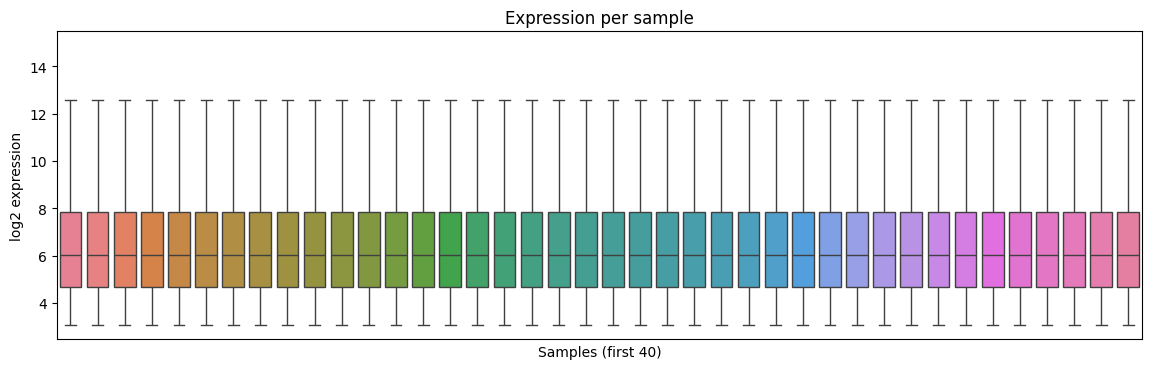

In [5]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=expr.iloc[:, :40], fliersize=0)
plt.xticks([])
plt.xlabel("Samples (first 40)")
plt.ylabel("log2 expression")
plt.title("Expression per sample")
plt.savefig("results/qc_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Cleaning: probes to genes

Probe IDs (e.g. `201234_at`) have no biological meaning on their own, so they are mapped to gene symbols:

1. Keep only probes with a gene symbol and drop probes that match several genes (`///`)
2. Average multiple probes of the same gene into one value per gene
3. Remove the 25% least-variable genes (mostly noise; this uses no group labels)

In [6]:
print("Probes at start:", expr.shape[0])

gpl = list(gse.gpls.values())[0]

annot = gpl.table[["ID", "Gene Symbol"]].dropna()
annot.columns = ["probe", "gene"]
annot["probe"] = annot["probe"].astype(str)
annot = annot[~annot["gene"].str.contains("///")]
annot = annot[annot["gene"].str.strip() != ""]

expr.index = expr.index.astype(str)
expr = expr[expr.index.isin(annot["probe"])]
print("Probes with one gene:", expr.shape[0])

expr.index = expr.index.map(annot.set_index("probe")["gene"])
expr = expr.groupby(expr.index).mean()
print("Unique genes:", expr.shape[0])

variance = expr.var(axis=1)
expr = expr[variance > variance.quantile(0.25)]
print("Genes after variance filter:", expr.shape[0])

meta[["title", "patient", "group"]].to_csv("data/sample_labels.csv")
expr.to_csv("data/expression_clean.csv")

Probes at start: 54675
Probes with one gene: 42986
Unique genes: 21655
Genes after variance filter: 16241


## 4. PCA

PCA compresses thousands of genes into a few axes so we can see whether samples group by tumor/normal. Genes are standardized first so that highly expressed genes do not dominate.

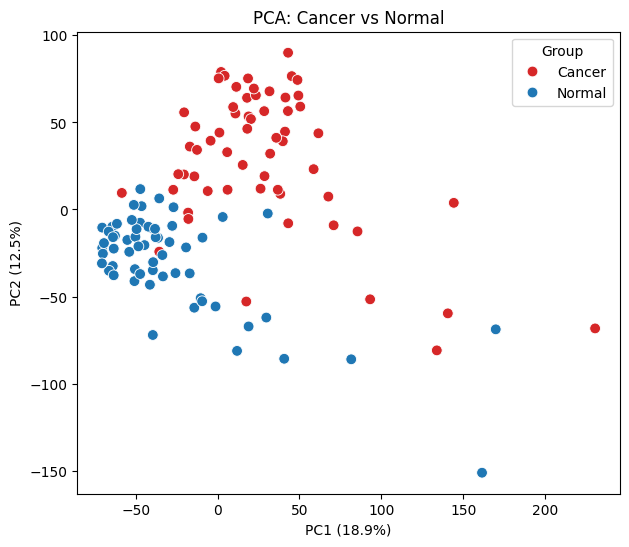

In [7]:
X_scaled = StandardScaler().fit_transform(expr.T)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"], index=expr.columns)
pca_df["Group"] = meta["group"]

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Group", palette=COLORS, s=60)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA: Cancer vs Normal")
plt.savefig("results/pca_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Tumor and normal samples separate partially, with a few samples far from the main cloud. Which samples are they, and does the metadata explain them? (No samples are removed, because there is no documented technical reason.)

In [8]:
outliers = pca_df[(pca_df["PC1"] > 80) | (pca_df["PC2"] < -80)].join(meta[["title"]])
print(outliers[["title", "Group", "PC1", "PC2"]])

meta["outlier"] = meta.index.isin(outliers.index)
print("\nGender:", meta["characteristics_ch1.1.gender"].value_counts().to_dict())
print("\nStage of outlier vs non-outlier samples:")
print(meta.groupby("outlier")["characteristics_ch1.3.stage"].value_counts())
for c in ["extract_protocol_ch1", "hyb_protocol", "scan_protocol"]:
    print(c, "unique values:", meta[c].nunique())

                      title   Group         PC1         PC2
name                                                       
GSM494571  Lung Cancer 103T  Cancer   93.166476  -51.578846
GSM494572  Lung Cancer 106T  Cancer   85.459945  -12.587143
GSM494590  Lung Cancer 131T  Cancer  140.636215  -59.651498
GSM494591  Lung Cancer 132T  Cancer  144.284101    3.825152
GSM494594  Lung Cancer 135T  Cancer  133.904475  -80.905008
GSM494596  Lung Cancer 137T  Cancer  230.631249  -68.287571
GSM494650  Lung Normal 131N  Normal   40.670560  -85.712333
GSM494651  Lung Normal 132N  Normal   11.859191  -81.192135
GSM494654  Lung Normal 135N  Normal  161.534908 -151.155206
GSM494656  Lung Normal 137N  Normal   81.622726  -86.027350
GSM494657  Lung Normal 139N  Normal  169.909020  -68.819341

Gender: {'female': 120}

Stage of outlier vs non-outlier samples:
outlier  characteristics_ch1.3.stage
False    n/a                            55
         1B                             17
         1A                   

Connecting each patient's tumor and normal sample shows that most patients shift in the same direction (the tumor signal). The outliers are largely **patient-level**: both samples from the same patient move together, so the paired test below, which compares each tumor with its own normal tissue, is robust to them.

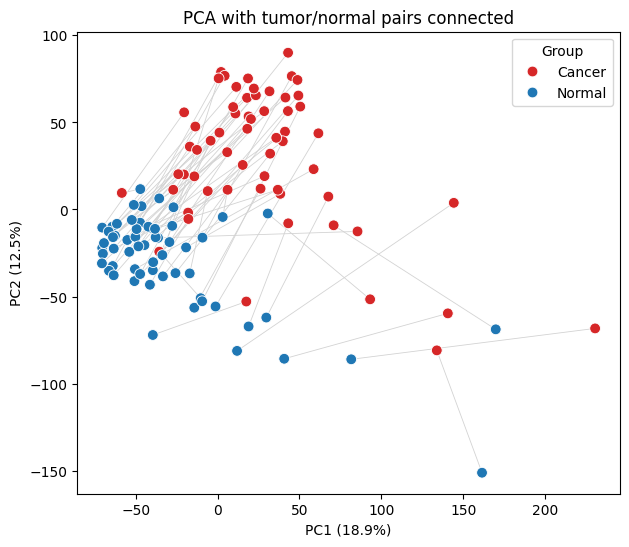

In [9]:
plt.figure(figsize=(7, 6))
for p in meta["patient"].unique():
    pair = pca_df[meta["patient"] == p]
    plt.plot(pair["PC1"], pair["PC2"], c="lightgrey", lw=0.6, zorder=1)
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Group", palette=COLORS, s=60, zorder=2)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA with tumor/normal pairs connected")
plt.savefig("results/pca_paired.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Differential expression (paired)

For every gene, a **paired t-test** compares each tumor with the same patient's normal tissue. Because the data are already log2-scaled, the **log2 fold change** is the mean paired difference (tumor minus normal). **Benjamini-Hochberg FDR** corrects for testing about 16,000 genes at once.

In [10]:
cancer_ids = meta[meta["group"] == "Cancer"].sort_values("patient")
normal_ids = meta[meta["group"] == "Normal"].sort_values("patient")
print("Pairs aligned:", cancer_ids["patient"].tolist() == normal_ids["patient"].tolist())

cancer = expr[cancer_ids.index]
normal = expr[normal_ids.index]

t_stat, p_vals = stats.ttest_rel(cancer.values, normal.values, axis=1)

de = pd.DataFrame({
    "gene": expr.index,
    "log2FC": (cancer.values - normal.values).mean(axis=1),
    "pvalue": p_vals,
})
de["FDR"] = multipletests(de["pvalue"], method="fdr_bh")[1]
de["neg_log10_FDR"] = -np.log10(de["FDR"].clip(lower=1e-300))
de["mean_expr"] = expr.mean(axis=1).values

def classify(row):
    if row["FDR"] < FDR_CUT and row["log2FC"] > FC_CUT:
        return "Up"
    if row["FDR"] < FDR_CUT and row["log2FC"] < -FC_CUT:
        return "Down"
    return "NS"

de["status"] = de.apply(classify, axis=1)
print(de["status"].value_counts())

Pairs aligned: True
status
NS      15424
Down      546
Up        271
Name: count, dtype: int64


## 6. Biomarker tables and plots

Two rankings of the significant genes are produced, because they surface different genes:

- **By effect size** (largest log2 fold change)
- **By statistical significance** (smallest p-value; FDR is shown as well)

In [11]:
sig = de[de["status"] != "NS"]

top_up = sig[sig["status"] == "Up"].sort_values("log2FC", ascending=False).head(10)
top_down = sig[sig["status"] == "Down"].sort_values("log2FC").head(10)
biomarkers = pd.concat([top_up, top_down])[["gene", "log2FC", "pvalue", "FDR", "status"]]

top_up_p = sig[sig["status"] == "Up"].sort_values("pvalue").head(10)
top_down_p = sig[sig["status"] == "Down"].sort_values("pvalue").head(10)
biomarkers_sig = pd.concat([top_up_p, top_down_p])[["gene", "log2FC", "pvalue", "FDR", "status"]]

biomarkers.to_csv("results/biomarker_table.csv", index=False)
biomarkers_sig.to_csv("results/biomarker_table_by_FDR.csv", index=False)   # ranked by significance
de.to_csv("results/full_DE_results.csv", index=False)

print("Genes in both top-10 lists:", sorted(set(biomarkers["gene"]) & set(biomarkers_sig["gene"])))
biomarkers

Genes in both top-10 lists: ['AGER', 'CA4', 'COL10A1', 'CTHRC1']


,gene,log2FC,pvalue,FDR,status
2869,COL10A1,4.028263,2.882673e-23,1.672053e-20,Up
13462,SPINK1,3.339114,4.035471e-11,3.502944e-10,Up
3226,CTHRC1,3.193161,7.116331e-21,1.359722e-18,Up
8771,MMP12,3.175403,1.084548e-14,2.386741e-13,Up
8768,MMP1,3.042188,2.352290e-11,2.155956e-10,Up
3135,CST1,2.989629,6.078430e-17,2.716406e-15,Up
2870,COL11A1,2.969864,5.488348e-15,1.324462e-13,Up
5544,GREM1,2.867474,3.375129e-13,4.774867e-12,Up
13482,SPP1,2.779812,7.036567e-20,9.523407e-18,Up
6049,HS6ST2,2.696565,3.858031e-17,1.870396e-15,Up


In [12]:
biomarkers_sig

,gene,log2FC,pvalue,FDR,status
5398,GOLM1,1.013591,6.220319e-25,1.040438e-21,Up
4171,ENC1,1.255628,1.060868e-24,1.325350e-21,Up
9782,OCIAD2,1.788121,8.902907e-24,6.286614e-21,Up
11223,PYCR1,1.314959,1.262147e-23,8.199413e-21,Up
2869,COL10A1,4.028263,2.882673e-23,1.672053e-20,Up
5019,FUT2,1.338079,8.706602e-23,4.284967e-20,Up
4019,EFNA4,1.610927,1.469677e-21,3.672156e-19,Up
3226,CTHRC1,3.193161,7.116331e-21,1.359722e-18,Up
5230,GGCT,1.169689,1.077712e-20,1.988991e-18,Up
47,ABCC3,1.148315,2.088911e-20,3.461836e-18,Up


**Volcano plot:** each dot is a gene; the x-axis is the size of the change and the y-axis is how reliable it is. Dashed lines mark the thresholds.

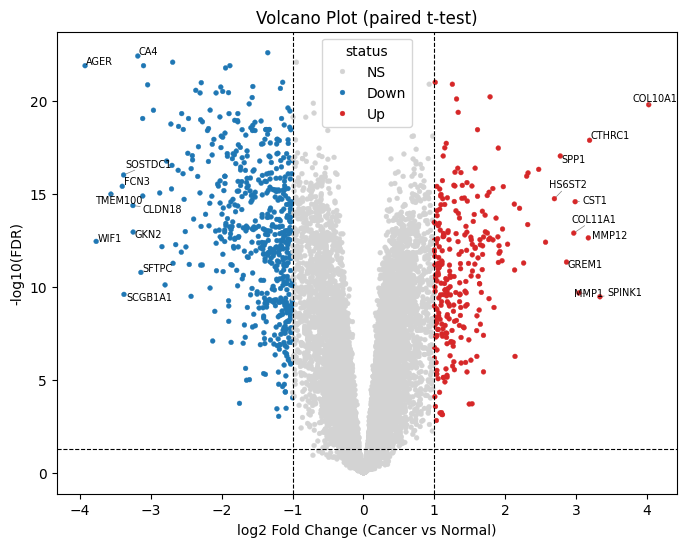

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=de, x="log2FC", y="neg_log10_FDR", hue="status",
                palette=STATUS_COLORS, s=12, edgecolor=None)
plt.axvline(FC_CUT, ls="--", c="black", lw=0.8)
plt.axvline(-FC_CUT, ls="--", c="black", lw=0.8)
plt.axhline(-np.log10(FDR_CUT), ls="--", c="black", lw=0.8)

texts = [plt.text(r["log2FC"], r["neg_log10_FDR"], r["gene"], fontsize=7)
         for _, r in pd.concat([top_up, top_down]).iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))

plt.xlabel("log2 Fold Change (Cancer vs Normal)")
plt.ylabel("-log10(FDR)")
plt.title("Volcano Plot (paired t-test)")
plt.savefig("results/volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()

**Heatmap** of the top 10 up and top 10 down genes. Each gene is z-scored across samples, so colors show relative up/down. These genes were chosen because they differ between groups, so the clean separation is partly circular; the classifier and the independent cohort below provide the real evidence.

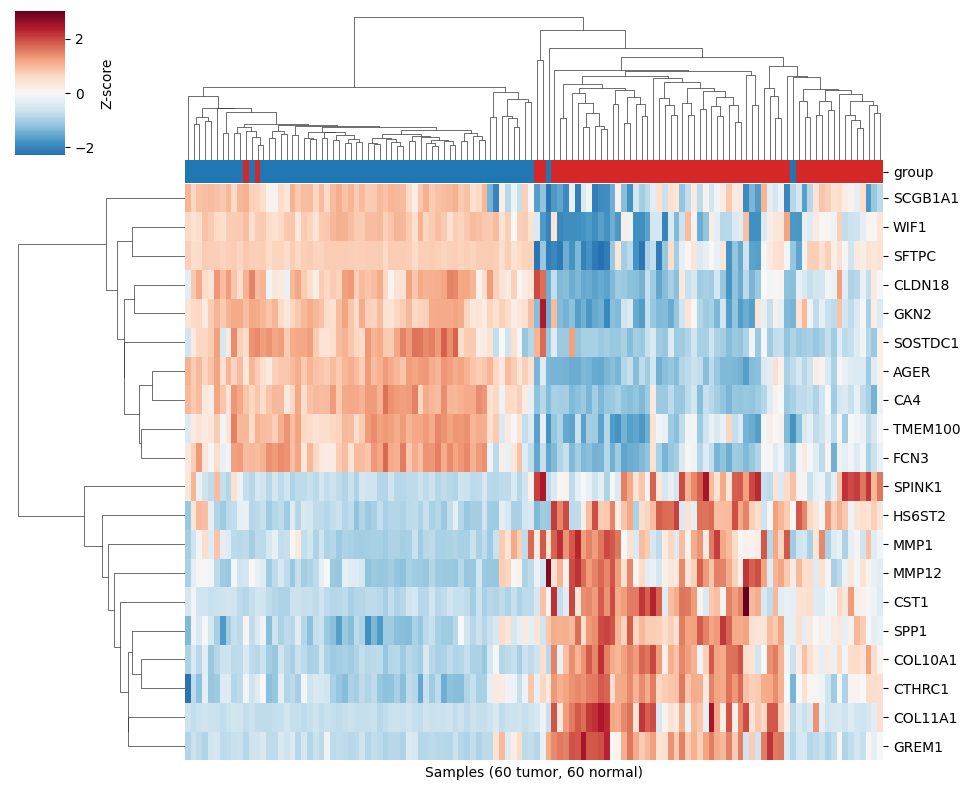

In [14]:
genes = pd.concat([top_up, top_down])["gene"].tolist()
cols = list(cancer_ids.index) + list(normal_ids.index)
heat = expr.loc[genes, cols]
col_colors = meta.loc[cols, "group"].map(COLORS)

g = sns.clustermap(heat, z_score=0, cmap="RdBu_r", center=0,
                   col_colors=col_colors, xticklabels=False,
                   figsize=(10, 8), cbar_kws={"label": "Z-score"})
g.ax_heatmap.set_xlabel("Samples (60 tumor, 60 normal)")
g.ax_heatmap.set_ylabel("")
g.savefig("results/heatmap.png", dpi=300)
plt.show()

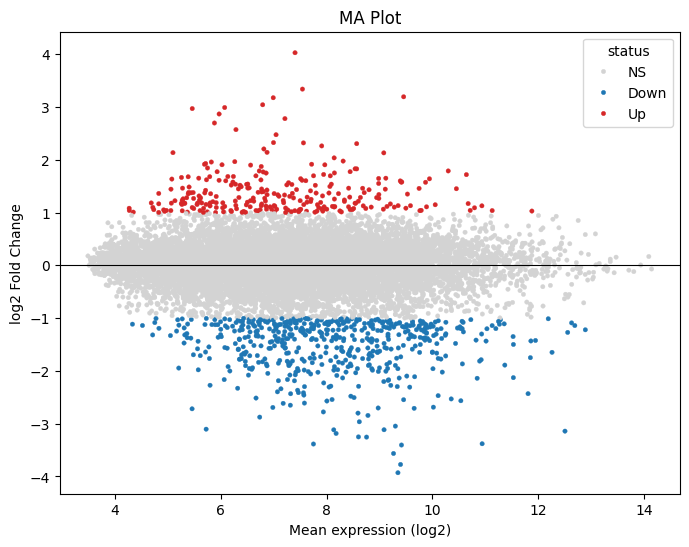

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=de, x="mean_expr", y="log2FC", hue="status",
                palette=STATUS_COLORS, s=10, edgecolor=None)
plt.axhline(0, c="black", lw=0.8)
plt.xlabel("Mean expression (log2)")
plt.ylabel("log2 Fold Change")
plt.title("MA Plot")
plt.savefig("results/ma_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Check against the published biomarker (SEMA5A)

The original study of this cohort reported **SEMA5A** as a biomarker (lower in tumors). Does this analysis reproduce it, and where does it rank?

In [16]:
gene = "SEMA5A"
row = de[de["gene"] == gene]

if row.empty:
    print(gene, "is not in the filtered gene table")
else:
    print(row[["gene", "log2FC", "pvalue", "FDR", "status"]].to_string(index=False))

    fdr_rank = de.sort_values("FDR").reset_index(drop=True)
    print("Rank by FDR:", fdr_rank.index[fdr_rank["gene"] == gene][0] + 1, "of", len(de))

    if row["status"].iloc[0] == "Down":
        down = de[de["status"] == "Down"].sort_values("log2FC").reset_index(drop=True)
        print("Rank among downregulated genes (by log2FC):",
              down.index[down["gene"] == gene][0] + 1, "of", len(down))

  gene    log2FC       pvalue          FDR status
SEMA5A -1.564274 1.359724e-21 3.620210e-19   Down
Rank by FDR: 61 of 16241
Rank among downregulated genes (by log2FC): 200 of 546


SEMA5A is clearly downregulated. It is not in the top 10 by fold change because its drop (about 3-fold) is moderate, but it is highly consistent across patients, which is why it ranks much higher by FDR.

## 8. Classifier with leakage-safe cross-validation

Can 20 genes tell tumor from normal? Two choices keep the estimate honest:

- **Gene selection happens inside each cross-validation fold** (it is part of the pipeline), so held-out samples never influence which genes are chosen.
- **`GroupKFold` keeps both samples of a patient in the same fold**, so the model is never trained on a patient's tumor and tested on the same patient's normal.

Cross-validated AUC: 0.983
Cross-validated accuracy: 0.958


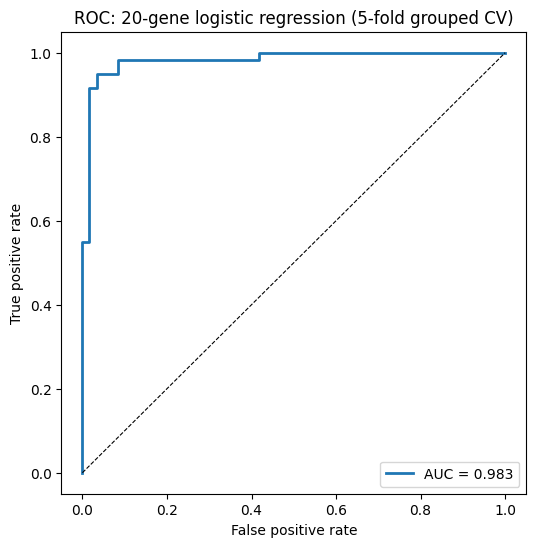

In [17]:
X = expr.T
assert list(X.index) == list(meta.index)

y = (meta["group"] == "Cancer").astype(int).values
groups = meta["patient"].values

def make_pipe():
    return Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectKBest(f_classif, k=20)),
        ("clf", LogisticRegression(max_iter=1000)),
    ])

pipe = make_pipe()
proba = cross_val_predict(pipe, X, y, cv=GroupKFold(n_splits=5),
                          groups=groups, method="predict_proba")[:, 1]

auc = roc_auc_score(y, proba)
acc = ((proba > 0.5) == y).mean()
print(f"Cross-validated AUC: {auc:.3f}")
print(f"Cross-validated accuracy: {acc:.3f}")

fpr, tpr, _ = roc_curve(y, proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=0.8)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC: 20-gene logistic regression (5-fold grouped CV)")
plt.legend()
plt.savefig("results/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

**Which samples were misclassified, and does each patient's tumor still score higher than their own normal tissue?**

In [18]:
pred = (proba > 0.5).astype(int)
miss = pred != y
wrong = meta.loc[miss, ["title", "group", "characteristics_ch1.3.stage"]].copy()
wrong["cancer_probability"] = proba[miss].round(3)
print(wrong)

score = pd.Series(proba, index=meta.index)
tumor_score = score[cancer_ids.index].values
normal_score = score[normal_ids.index].values
print("\nPatients where the tumor scored higher than its own normal:",
      (tumor_score > normal_score).sum(), "of", len(tumor_score))

                      title   group characteristics_ch1.3.stage  \
GSM494569   Lung Cancer 97T  Cancer                          1A   
GSM494594  Lung Cancer 135T  Cancer                          1A   
GSM494605  Lung Cancer 152T  Cancer                          1A   
GSM494657  Lung Normal 139N  Normal                         n/a   
GSM494675  Lung Normal 189N  Normal                         n/a   

           cancer_probability  
GSM494569               0.209  
GSM494594               0.212  
GSM494605               0.012  
GSM494657               0.988  
GSM494675               0.718  

Patients where the tumor scored higher than its own normal: 59 of 60


**Genes used by the final model** (fit on all samples only to display them; performance above comes from cross-validation). Do not read individual coefficients as "up or down in cancer": the selected genes are correlated, so some coefficients have the opposite sign of the gene's actual change (use the log2FC from section 5 for direction).

In [19]:
final_pipe = make_pipe().fit(X, y)
selected = final_pipe.named_steps["select"].get_support()
coefs = final_pipe.named_steps["clf"].coef_[0]

model_genes = pd.DataFrame({"gene": X.columns[selected], "coefficient": coefs}) \
                .sort_values("coefficient")
model_genes.to_csv("results/classifier_genes.csv", index=False)
model_genes

,gene,coefficient
5,DENND3,-0.756505
18,SPOCK2,-0.754560
10,GRK5,-0.559236
7,FRMD3,-0.332366
16,SERTM1,-0.303662
15,RTKN2,-0.268296
12,KANK3,-0.222375
13,NCKAP5,-0.195884
1,AGER,-0.125946
19,SPTBN1,-0.052479


## 9. External validation (GSE18842)

The model is trained on GSE19804 only and applied **once** to an independent lung cancer dataset, GSE18842 (46 tumor and 45 control samples, same GPL570 platform), without any retraining or tuning.

In [20]:
gse2 = GEOparse.get_GEO(geo="GSE18842", destdir="data/")
meta2 = gse2.phenotype_data

meta2["group"] = np.where(meta2["characteristics_ch1.1.sample type"] == "tumor", "Cancer", "Normal")
print(meta2["group"].value_counts())

expr2 = gse2.pivot_samples("VALUE")
expr2 = expr2[meta2.index]
print("Shape (probes x samples):", expr2.shape)
print("Missing values:", expr2.isna().sum().sum())
print("Min:", expr2.min().min(), "| Max:", expr2.max().max())

100%|██████████| 40.7M/40.7M [00:00<00:00, 86.6MB/s]
/usr/local/lib/python3.13/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


group
Cancer    46
Normal    45
Name: count, dtype: int64
Shape (probes x samples): (54675, 91)
Missing values: 0
Min: 2.44683 | Max: 14.7444


Quality check: the validation data are on a similar log2 scale but sit at a **lower overall level** (box medians about 4.5 versus 6), which suggests different preprocessing. This matters for a fixed classification cutoff, so results are reported with and without per-gene standardization.

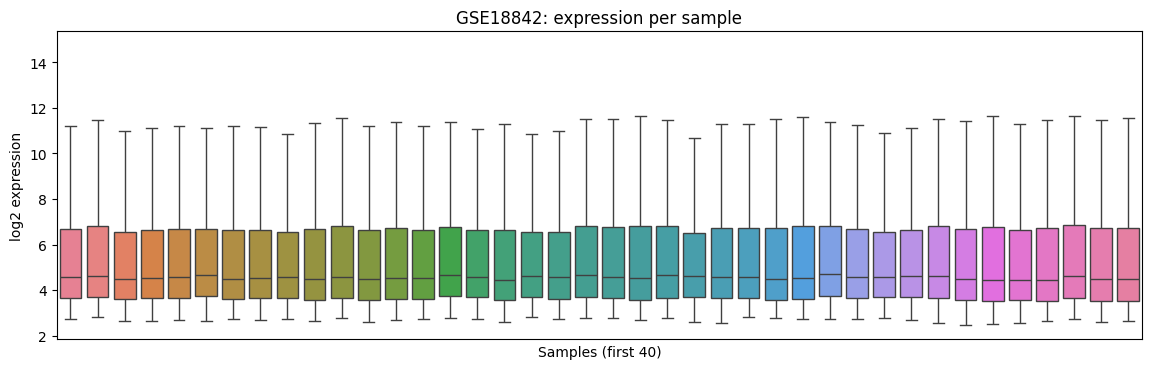

In [21]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=expr2.iloc[:, :40], fliersize=0)
plt.xticks([])
plt.xlabel("Samples (first 40)")
plt.ylabel("log2 expression")
plt.title("GSE18842: expression per sample")
plt.show()

In [22]:
expr2.index = expr2.index.astype(str)
expr2 = expr2[expr2.index.isin(annot["probe"])]
expr2.index = expr2.index.map(annot.set_index("probe")["gene"])
expr2 = expr2.groupby(expr2.index).mean()

shared = [g for g in expr.index if g in expr2.index]
print("Genes in discovery table:", expr.shape[0])
print("Genes in validation table:", expr2.shape[0])
print("Shared genes:", len(shared))

Genes in discovery table: 16241
Genes in validation table: 21655
Shared genes: 16241


**Train on GSE19804, test on GSE18842.** Version B z-scores each gene within its own dataset (no labels used) to remove dataset-level offsets. Gene selection uses only GSE19804.

A) No harmonization:  AUC = 0.9995   Accuracy = 0.934
B) Per-gene z-score:  AUC = 0.9995   Accuracy = 0.978


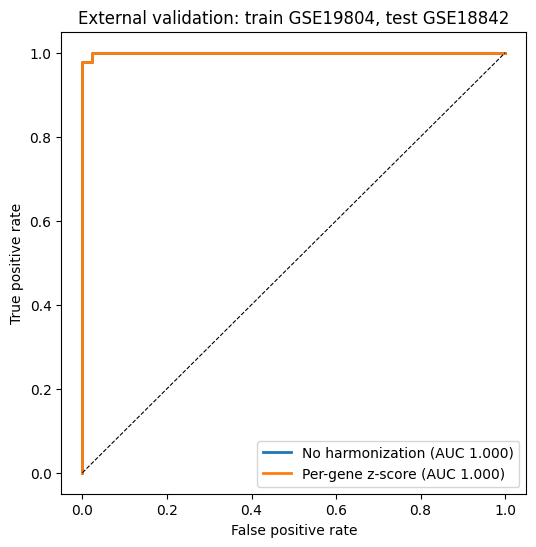


Misclassified in validation (version B):
                title   group  cancer_probability
GSM466955  Control 10  Normal               0.516
GSM467037  Control 66  Normal               0.690


In [23]:
X_train = expr.loc[shared].T
X_test = expr2.loc[shared].T
y_train = (meta["group"] == "Cancer").astype(int).values
y_test = (meta2["group"] == "Cancer").astype(int).values

assert list(X_train.index) == list(meta.index)
assert list(X_test.index) == list(meta2.index)
assert list(X_train.columns) == list(X_test.columns)

def zscore_genes(df):
    sd = df.std(axis=0).replace(0, 1)          # guard against constant genes
    return (df - df.mean(axis=0)) / sd

# A) no harmonization
pipe_a = make_pipe().fit(X_train, y_train)
p_a = pipe_a.predict_proba(X_test)[:, 1]
auc_a = roc_auc_score(y_test, p_a)
acc_a = ((p_a > 0.5) == y_test).mean()

# B) per-gene z-score within each dataset
pipe_b = make_pipe().fit(zscore_genes(X_train), y_train)
p_b = pipe_b.predict_proba(zscore_genes(X_test))[:, 1]
auc_b = roc_auc_score(y_test, p_b)
acc_b = ((p_b > 0.5) == y_test).mean()

print(f"A) No harmonization:  AUC = {auc_a:.4f}   Accuracy = {acc_a:.3f}")
print(f"B) Per-gene z-score:  AUC = {auc_b:.4f}   Accuracy = {acc_b:.3f}")

plt.figure(figsize=(6, 6))
for p, name in [(p_a, f"No harmonization (AUC {auc_a:.3f})"),
                (p_b, f"Per-gene z-score (AUC {auc_b:.3f})")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, lw=2, label=name)
plt.plot([0, 1], [0, 1], "k--", lw=0.8)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("External validation: train GSE19804, test GSE18842")
plt.legend(loc="lower right")
plt.savefig("results/roc_validation.png", dpi=300, bbox_inches="tight")
plt.show()

miss_b = (p_b > 0.5) != y_test
wrong_b = meta2.loc[miss_b, ["title", "group"]].copy()
wrong_b["cancer_probability"] = p_b[miss_b].round(3)
print("\nMisclassified in validation (version B):")
print(wrong_b)

**Do the gene-level findings replicate?** The validation differential expression uses an unpaired Welch test (GSE18842 is not fully paired), so its FDR values are not directly comparable with the paired discovery test. Compare directions and effect-size correlation instead.

In [24]:
c2 = expr2.loc[shared, meta2["group"] == "Cancer"]
n2 = expr2.loc[shared, meta2["group"] == "Normal"]

t2, pv2 = stats.ttest_ind(c2.values, n2.values, axis=1, equal_var=False)
val = pd.DataFrame({"gene": shared,
                    "log2FC_val": (c2.mean(axis=1) - n2.mean(axis=1)).values,
                    "p_val": pv2})
val["FDR_val"] = multipletests(val["p_val"], method="fdr_bh")[1]

cmp = de.merge(val, on="gene")
print("Spearman correlation of log2FC (discovery vs validation):",
      round(cmp["log2FC"].corr(cmp["log2FC_val"], method="spearman"), 3))

sig_disc = cmp[cmp["status"] != "NS"]
same_dir = (np.sign(sig_disc["log2FC"]) == np.sign(sig_disc["log2FC_val"])).mean()
print(f"Significant discovery genes with the same direction in validation: "
      f"{same_dir:.1%} of {len(sig_disc)}")

print(cmp[cmp["gene"] == "SEMA5A"][["gene", "log2FC", "log2FC_val", "FDR_val"]].to_string(index=False))

Spearman correlation of log2FC (discovery vs validation): 0.73
Significant discovery genes with the same direction in validation: 98.0% of 817
  gene    log2FC  log2FC_val      FDR_val
SEMA5A -1.564274   -1.506343 2.676441e-12


## 10. Pathway enrichment (GO Biological Process)

What do the up and down genes do? Enrichr (via `gseapy`) tests whether the gene lists are enriched for known biological processes. Many top terms overlap (for example several spindle-checkpoint terms contain the same genes), so read them as themes.

In [25]:
up_genes = de[de["status"] == "Up"]["gene"].tolist()
down_genes = de[de["status"] == "Down"]["gene"].tolist()
print(len(up_genes), "up genes,", len(down_genes), "down genes")

enr_up = gp.enrichr(gene_list=up_genes, gene_sets="GO_Biological_Process_2023",
                    organism="human", outdir=None)
enr_down = gp.enrichr(gene_list=down_genes, gene_sets="GO_Biological_Process_2023",
                      organism="human", outdir=None)

print(enr_up.results[["Term", "Adjusted P-value", "Overlap"]].head(10))
print(enr_down.results[["Term", "Adjusted P-value", "Overlap"]].head(10))

271 up genes, 546 down genes
                                                Term  Adjusted P-value Overlap
0  Extracellular Structure Organization (GO:0043062)      1.816270e-08  15/109
1  External Encapsulating Structure Organization ...      1.816270e-08  15/110
2     Extracellular Matrix Organization (GO:0030198)      1.206264e-06  16/176
3  Mitotic Sister Chromatid Segregation (GO:0000070)      1.352168e-06  13/111
4  Microtubule Cytoskeleton Organization Involved...      1.867065e-06   10/59
5          Mitotic Spindle Organization (GO:0007052)      5.100467e-06   11/85
6  Spindle Assembly Checkpoint Signaling (GO:0071...      1.798817e-04    6/26
7  Mitotic Spindle Assembly Checkpoint Signaling ...      1.798817e-04    6/26
8  Mitotic Spindle Checkpoint Signaling (GO:0071174)      1.798817e-04    6/26
9          Collagen Fibril Organization (GO:0030199)      2.105111e-04    7/42
                                                Term  Adjusted P-value Overlap
0                 Infla

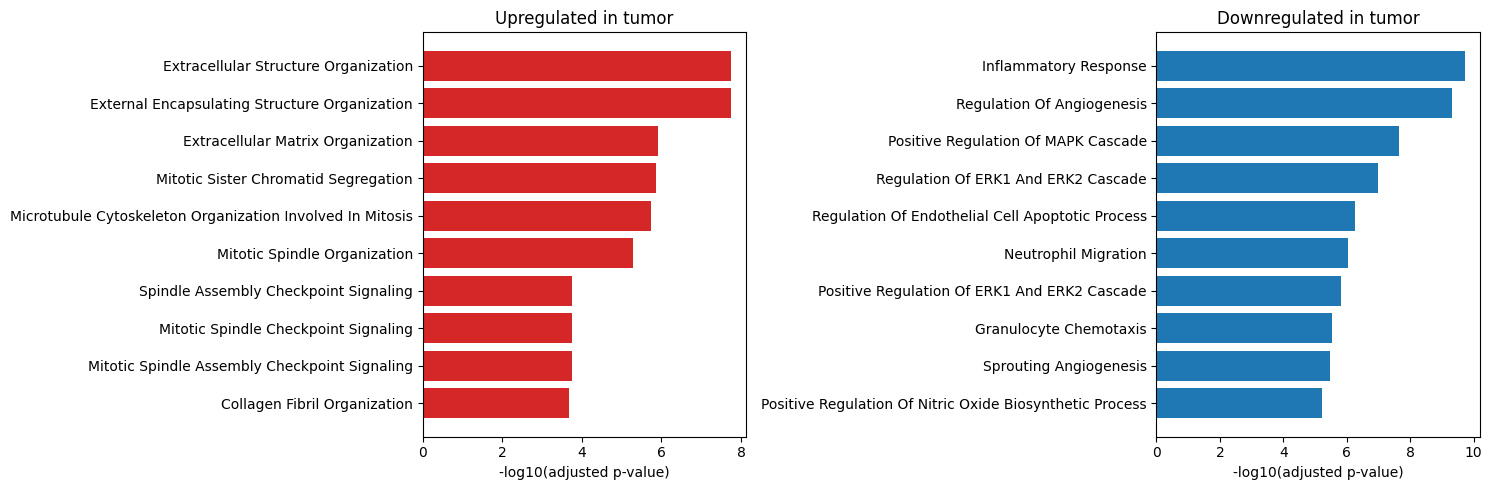

In [26]:
def top_terms(enr, n=10):
    r = enr.results.sort_values("Adjusted P-value").head(n).copy()
    r["Term"] = r["Term"].str.replace(r" \(GO:\d+\)", "", regex=True)
    r["neg_log10_adjP"] = -np.log10(r["Adjusted P-value"])
    return r

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, enr, title, color in [(axes[0], enr_up, "Upregulated in tumor", "#d62728"),
                              (axes[1], enr_down, "Downregulated in tumor", "#1f77b4")]:
    r = top_terms(enr)
    ax.barh(r["Term"][::-1], r["neg_log10_adjP"][::-1], color=color)
    ax.set_xlabel("-log10(adjusted p-value)")
    ax.set_title(title)
plt.tight_layout()
plt.savefig("results/pathway_enrichment.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Summary and limitations

**Findings**

- 54,675 probes were cleaned to 16,241 genes across 60 paired tumor/normal samples.
- Paired differential expression found **817 genes** (271 up, 546 down; FDR < 0.05, |log2FC| > 1).
- **SEMA5A**, the biomarker reported by the original study, is significantly downregulated here (log2FC about -1.56) and replicates in the independent cohort.
- A 20-gene logistic regression reached a **cross-validated AUC of 0.983** (patient-grouped folds) and an **AUC of about 1.0 on GSE18842** (accuracy 97.8% after per-gene standardization).
- 98% of the significant genes changed in the same direction in the independent cohort.
- Upregulated genes are enriched for extracellular matrix organization and mitotic processes; downregulated genes for inflammatory response, angiogenesis and ERK/MAPK regulation.

**Limitations**

- Tumor versus adjacent normal tissue is a high-contrast comparison, so a near-perfect AUC does not make this a clinical diagnostic test. These are candidate biomarkers.
- Both cohorts use the same platform (GPL570) and are tissue-based; cross-platform and blood-based performance were not tested.
- Many downregulated genes likely reflect differences in cell composition (fewer alveolar, vascular and immune cells in tumors), not only gene regulation inside cells.
- Classifier coefficients are not reliable indicators of per-gene direction because the selected genes are correlated.
- The validation differential expression is unpaired, and per-gene z-scoring used the test cohort's own distribution.
- Enrichment used Enrichr's default background; many top terms are redundant.
- The cohort is single-sex, non-smoking, from Taiwan and mostly early stage. The cause of the PCA outliers could not be determined from the GEO metadata.

### Appendix: software versions and optional download

In [27]:
import importlib.metadata as md
for p in ["pandas", "numpy", "scipy", "statsmodels", "scikit-learn", "seaborn",
          "matplotlib", "GEOparse", "gseapy", "adjustText"]:
    try:
        print(f"{p}=={md.version(p)}")
    except Exception:
        print(p, "not installed")

print("\nFiles in results/:", sorted(os.listdir("results")))

pandas==2.2.3
numpy==2.1.3
scipy==1.16.3
statsmodels==0.15.0
scikit-learn==1.6.1
seaborn==0.13.2
matplotlib==3.10.0
GEOparse==2.0.4
gseapy==1.3.1
adjustText==1.4.0

Files in results/: ['biomarker_table.csv', 'biomarker_table_by_FDR.csv', 'classifier_genes.csv', 'full_DE_results.csv', 'heatmap.png', 'ma_plot.png', 'pathway_enrichment.png', 'pca_paired.png', 'pca_plot.png', 'qc_boxplot.png', 'roc_curve.png', 'roc_validation.png', 'volcano_plot.png']


In [29]:
DOWNLOAD_RESULTS = False   # set to True in Colab to download a zip of the results folder

if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        os.system("zip -r -q results.zip results")
        files.download("results.zip")
    except ImportError:
        print("Not running in Colab; the figures and tables are in the 'results/' folder.")